# Benchmark XGBoost — Risque de crédit

## Objectif

Construire un modèle XGBoost de probabilité de défaut et le comparer à la scorecard logistique WoE V1.

La comparaison porte sur la capacité de discrimination, la calibration, la stabilité temporelle et l'utilité métier des deux approches.

## Règles méthodologiques

- Le split temporel est strictement conservé :
  - Train : 2007 à 2013
  - Validation : 2014
  - Test final : 2015
- Le test final ne sert pas au réglage des hyperparamètres.
- XGBoost utilisera les mêmes variables métier initiales que la scorecard V1, sans transformation WoE.
- La sélection du modèle repose sur la validation ; le test sert à l'évaluation finale et à la comparaison avec la scorecard.
- Les métriques suivies sont AUC-ROC, AUC-PR, Gini, KS, Brier, calibration, déciles de risque et PSI.

## Positionnement métier

La scorecard est le modèle de référence interprétable. XGBoost est un challenger non linéaire : il doit démontrer un gain de performance stable et significatif pour justifier une gouvernance plus complexe.


In [3]:
# ============================================================
# 1. INITIALISATION
# ============================================================

from pathlib import Path
import json
import pickle
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

# Reproductibilité.
RANDOM_STATE = 42

# Chemins du projet.
PROJECT_DIR = Path.cwd().parent
DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_TABLES_DIR = OUTPUT_DIR / "tables"
OUTPUT_MODELS_DIR = OUTPUT_DIR / "models"

for directory in [
    OUTPUT_FIGURES_DIR,
    OUTPUT_TABLES_DIR,
    OUTPUT_MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Cible.
TARGET = "default_flag"

# Paramètres visuels.
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

print(f"Projet : {PROJECT_DIR}")
print(f"Données : {DATA_PROCESSED_DIR}")
print(f"Tables : {OUTPUT_TABLES_DIR}")
print(f"Modèles : {OUTPUT_MODELS_DIR}")


Projet : /Users/kwamekristianlaban/Documents/Projet_perso/P2
Données : /Users/kwamekristianlaban/Documents/Projet_perso/P2/data/processed
Tables : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables
Modèles : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/models


In [4]:
#Chargement et référence
# ============================================================
# 2. CHARGEMENT DES PARTITIONS ET DU BENCHMARK SCORECARD
# ============================================================

TRAIN_FILE = DATA_PROCESSED_DIR / "train_v1.parquet"
VALIDATION_FILE = DATA_PROCESSED_DIR / "validation_v1.parquet"
TEST_FILE = DATA_PROCESSED_DIR / "test_v1.parquet"

SCORECARD_BENCHMARK_FILE = (
    OUTPUT_TABLES_DIR
    / "benchmark_scorecard_v1_avant_xgboost.csv"
)

train_df = pd.read_parquet(TRAIN_FILE)
validation_df = pd.read_parquet(VALIDATION_FILE)
test_df = pd.read_parquet(TEST_FILE)

benchmark_scorecard = pd.read_csv(
    SCORECARD_BENCHMARK_FILE
)

for split_name, dataframe in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    assert TARGET in dataframe.columns, (
        f"La cible '{TARGET}' est absente de {split_name}."
    )

print("Partitions chargées :")

for split_name, dataframe in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    print(
        f"{split_name:<12} | "
        f"{len(dataframe):>7,} prêts | "
        f"défaut : {dataframe[TARGET].mean():.2%}"
    )

print("\nRéférence scorecard :")
display(benchmark_scorecard)


Partitions chargées :
Train        | 172,988 prêts | défaut : 12.43%
Validation   | 162,570 prêts | défaut : 13.73%
Test         | 283,026 prêts | défaut : 14.89%

Référence scorecard :


,modèle,AUC_train,AUC_validation,AUC_test,Gini_test,KS_test,Brier_test,AUC_PR_train,AUC_PR_validation,AUC_PR_test,taux_defaut_test,PSI_score_train_test,PSI_variable_max,variable_PSI_max,version_probabilites
0,Scorecard logistique WoE V1,0.6389,0.6318,0.6300,0.2600,0.1885,0.1238,0.1888,0.1997,0.2126,0.1489,0.0131,0.0698,purpose,Initiale


## Préparation des variables pour XGBoost

Contrairement à la scorecard, XGBoost ne nécessite pas de transformation WoE ni de discrétisation des variables numériques.

Les valeurs manquantes sont imputées à partir des statistiques du train :
- médiane pour les variables numériques ;
- modalité la plus fréquente pour les variables catégorielles.

Les variables catégorielles sont encodées en one-hot encoding. Les modalités nouvelles observées en validation ou en test sont ignorées, afin d'éviter toute erreur au scoring et toute fuite d'information.


In [5]:
# ============================================================
# 3. DÉFINITION DES VARIABLES ET PRÉPARATION XGBOOST
# ============================================================

NUMERIC_FEATURES = [
    "fico_score",
    "dti",
    "revol_util",
    "loan_amnt",
    "annual_inc",
    "credit_history_months",
]

CATEGORICAL_FEATURES = [
    "home_ownership",
    "purpose",
    "verification_status",
]

FEATURES_V1 = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Vérification : mêmes variables métier que la scorecard V1.
for split_name, dataframe in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    missing_features = sorted(
        set(FEATURES_V1) - set(dataframe.columns)
    )

    assert not missing_features, (
        f"Variables absentes de {split_name} : "
        f"{missing_features}"
    )

# Séparation prédicteurs / cible.
X_train = train_df.loc[:, FEATURES_V1].copy()
y_train = train_df[TARGET].astype("int8").copy()

X_validation = validation_df.loc[:, FEATURES_V1].copy()
y_validation = validation_df[TARGET].astype("int8").copy()

X_test = test_df.loc[:, FEATURES_V1].copy()
y_test = test_df[TARGET].astype("int8").copy()

# Vue de contrôle des données manquantes par partition.
missingness_xgboost = pd.concat(
    {
        "Train": X_train.isna().mean(),
        "Validation": X_validation.isna().mean(),
        "Test": X_test.isna().mean(),
    },
    axis=1,
).reset_index()

missingness_xgboost.columns = [
    "variable",
    "missing_train",
    "missing_validation",
    "missing_test",
]

missingness_xgboost["max_missing"] = (
    missingness_xgboost[
        [
            "missing_train",
            "missing_validation",
            "missing_test",
        ]
    ]
    .max(axis=1)
)

missingness_xgboost = (
    missingness_xgboost
    .sort_values("max_missing", ascending=False)
    .reset_index(drop=True)
)

# Contrôle des modalités inconnues hors train.
modalites_nouvelles = []

for feature in CATEGORICAL_FEATURES:
    modalites_train = set(
        X_train[feature]
        .dropna()
        .astype(str)
        .unique()
    )

    for split_name, dataframe in {
        "Validation": X_validation,
        "Test": X_test,
    }.items():
        modalites_split = set(
            dataframe[feature]
            .dropna()
            .astype(str)
            .unique()
        )

        nouvelles_modalites = sorted(
            modalites_split - modalites_train
        )

        modalites_nouvelles.append(
            {
                "variable": feature,
                "split": split_name,
                "nb_modalites_train": len(modalites_train),
                "nb_modalites_nouvelles": len(
                    nouvelles_modalites
                ),
                "modalites_nouvelles": (
                    ", ".join(nouvelles_modalites)
                    if nouvelles_modalites
                    else "Aucune"
                ),
            }
        )

modalites_nouvelles = pd.DataFrame(
    modalites_nouvelles
)

# Pipeline de préparation : ajusté exclusivement sur train.
preprocesseur_xgboost = ColumnTransformer(
    transformers=[
        (
            "numeriques",
            Pipeline(
                steps=[
                    (
                        "imputation",
                        SimpleImputer(strategy="median"),
                    ),
                ]
            ),
            NUMERIC_FEATURES,
        ),
        (
            "categorie",
            Pipeline(
                steps=[
                    (
                        "imputation",
                        SimpleImputer(
                            strategy="most_frequent"
                        ),
                    ),
                    (
                        "one_hot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Le fit est réalisé uniquement sur les observations train.
X_train_prepared = preprocesseur_xgboost.fit_transform(
    X_train
)

X_validation_prepared = preprocesseur_xgboost.transform(
    X_validation
)

X_test_prepared = preprocesseur_xgboost.transform(
    X_test
)

# Noms des colonnes après transformation, utiles pour l'explicabilité.
FEATURES_XGBOOST = (
    preprocesseur_xgboost.get_feature_names_out().tolist()
)

X_train_prepared = pd.DataFrame(
    X_train_prepared,
    columns=FEATURES_XGBOOST,
    index=X_train.index,
)

X_validation_prepared = pd.DataFrame(
    X_validation_prepared,
    columns=FEATURES_XGBOOST,
    index=X_validation.index,
)

X_test_prepared = pd.DataFrame(
    X_test_prepared,
    columns=FEATURES_XGBOOST,
    index=X_test.index,
)

# Contrôles de cohérence.
assert list(X_train_prepared.columns) == list(
    X_validation_prepared.columns
)
assert list(X_train_prepared.columns) == list(
    X_test_prepared.columns
)
assert X_train_prepared.isna().sum().sum() == 0
assert X_validation_prepared.isna().sum().sum() == 0
assert X_test_prepared.isna().sum().sum() == 0

resume_preparation_xgboost = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "n_observations": [
            len(X_train_prepared),
            len(X_validation_prepared),
            len(X_test_prepared),
        ],
        "n_variables_apres_encodage": [
            X_train_prepared.shape[1],
            X_validation_prepared.shape[1],
            X_test_prepared.shape[1],
        ],
        "valeurs_manquantes_apres_preparation": [
            X_train_prepared.isna().sum().sum(),
            X_validation_prepared.isna().sum().sum(),
            X_test_prepared.isna().sum().sum(),
        ],
        "taux_defaut": [
            y_train.mean(),
            y_validation.mean(),
            y_test.mean(),
        ],
    }
)

print(
    f"Variables métier initiales : {len(FEATURES_V1)}"
)
print(
    "Variables après encodage : "
    f"{X_train_prepared.shape[1]}"
)

display(missingness_xgboost)
display(modalites_nouvelles)
display(resume_preparation_xgboost)


Variables métier initiales : 9
Variables après encodage : 27


,variable,missing_train,missing_validation,missing_test,max_missing
0,revol_util,0.0008,0.0005,0.0004,0.0008
1,dti,0.0000,0.0000,0.0000,0.0000
2,fico_score,0.0000,0.0000,0.0000,0.0000
3,loan_amnt,0.0000,0.0000,0.0000,0.0000
4,annual_inc,0.0000,0.0000,0.0000,0.0000
5,credit_history_months,0.0000,0.0000,0.0000,0.0000
6,home_ownership,0.0000,0.0000,0.0000,0.0000
7,purpose,0.0000,0.0000,0.0000,0.0000
8,verification_status,0.0000,0.0000,0.0000,0.0000


,variable,split,nb_modalites_train,nb_modalites_nouvelles,modalites_nouvelles
0,home_ownership,Validation,4,0,Aucune
1,home_ownership,Test,4,0,Aucune
2,purpose,Validation,14,0,Aucune
3,purpose,Test,14,0,Aucune
4,verification_status,Validation,3,0,Aucune
5,verification_status,Test,3,0,Aucune


,split,n_observations,n_variables_apres_encodage,valeurs_manquantes_apres_preparation,taux_defaut
0,Train,172988,27,0,0.1243
1,Validation,162570,27,0,0.1373
2,Test,283026,27,0,0.1489


### Analyse de la préparation

La préparation XGBoost est valide : aucune valeur manquante n'est observée dans les neuf variables retenues, ni dans le train, ni dans
les jeux de validation et de test.

Les trois variables catégorielles produisent au total 27 variables après encodage one-hot. La structure des variables est strictement identique dans les trois partitions et aucune modalité inconnue n'est observée hors train.

Le taux de défaut augmente de 12,43% sur le train à 14,89% sur le test. Cette dérive temporelle confirme que le test final constitue une évaluation réaliste de la robustesse du modèle sur un portefeuille futur plus risqué.


## XGBoost baseline

Le premier modèle XGBoost sert de référence avant l'optimisation des hyperparamètres.

Les choix sont volontairement conservateurs :
- arbres peu profonds afin de limiter le surapprentissage ;
- taux d'apprentissage faible ;
- sous-échantillonnage des lignes et des variables ;
- régularisation L1 et L2 ;
- arrêt anticipé sur la validation temporelle.

Le modèle est entraîné uniquement sur train. La validation 2014 décide du nombre optimal d'arbres. Le test 2015 reste strictement inutilisé à ce stade.


In [6]:
# ============================================================
# 4. ENTRAÎNEMENT DU MODÈLE XGBOOST BASELINE
# ============================================================

# Pondération des défauts : utile car la cible est déséquilibrée.
# Environ 7 prêts non-défaillants pour 1 prêt défaillant.
scale_pos_weight_train = (
    (y_train == 0).sum() / (y_train == 1).sum()
)

# Paramètres volontairement prudents pour le premier benchmark.
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric=["auc", "aucpr", "logloss"],
    n_estimators=2_000,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=20,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.00,
    gamma=0.00,
    scale_pos_weight=scale_pos_weight_train,
    early_stopping_rounds=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

# Le test final n'est jamais fourni au modèle à ce stade.
xgb_baseline.fit(
    X_train_prepared,
    y_train,
    eval_set=[
        (X_train_prepared, y_train),
        (X_validation_prepared, y_validation),
    ],
    verbose=100,
)

# Nombre d'arbres effectivement retenus par early stopping.
best_iteration_baseline = xgb_baseline.best_iteration
best_n_estimators_baseline = best_iteration_baseline + 1

# Probabilités issues du meilleur nombre d'arbres.
proba_train_xgb_baseline = xgb_baseline.predict_proba(
    X_train_prepared,
    iteration_range=(0, best_n_estimators_baseline),
)[:, 1]

proba_validation_xgb_baseline = xgb_baseline.predict_proba(
    X_validation_prepared,
    iteration_range=(0, best_n_estimators_baseline),
)[:, 1]

# Historique d'entraînement, utile pour vérifier l'overfitting.
historique_baseline = pd.DataFrame(
    xgb_baseline.evals_result()
)

historique_auc_baseline = pd.DataFrame(
    {
        "iteration": np.arange(
            len(historique_baseline["validation_0"]["auc"])
        ),
        "AUC_train": historique_baseline["validation_0"]["auc"],
        "AUC_validation": (
            historique_baseline["validation_1"]["auc"]
        ),
        "AUC_PR_train": (
            historique_baseline["validation_0"]["aucpr"]
        ),
        "AUC_PR_validation": (
            historique_baseline["validation_1"]["aucpr"]
        ),
        "logloss_train": (
            historique_baseline["validation_0"]["logloss"]
        ),
        "logloss_validation": (
            historique_baseline["validation_1"]["logloss"]
        ),
    }
)

print(
    "Poids de la classe défaut : "
    f"{scale_pos_weight_train:.2f}"
)
print(
    "Meilleure itération retenue : "
    f"{best_iteration_baseline}"
)
print(
    "Nombre d'arbres retenu : "
    f"{best_n_estimators_baseline}"
)



[0]	validation_0-auc:0.61596	validation_0-aucpr:0.16944	validation_0-logloss:0.69185	validation_1-auc:0.60629	validation_1-aucpr:0.18035	validation_1-logloss:0.69249
[100]	validation_0-auc:0.64732	validation_0-aucpr:0.19606	validation_0-logloss:0.66113	validation_1-auc:0.63760	validation_1-aucpr:0.20532	validation_1-logloss:0.68102
[200]	validation_0-auc:0.65455	validation_0-aucpr:0.20330	validation_0-logloss:0.65615	validation_1-auc:0.64225	validation_1-aucpr:0.20854	validation_1-logloss:0.67968
[275]	validation_0-auc:0.65752	validation_0-aucpr:0.20585	validation_0-logloss:0.65481	validation_1-auc:0.64348	validation_1-aucpr:0.20916	validation_1-logloss:0.68007
Poids de la classe défaut : 7.04
Meilleure itération retenue : 175
Nombre d'arbres retenu : 176


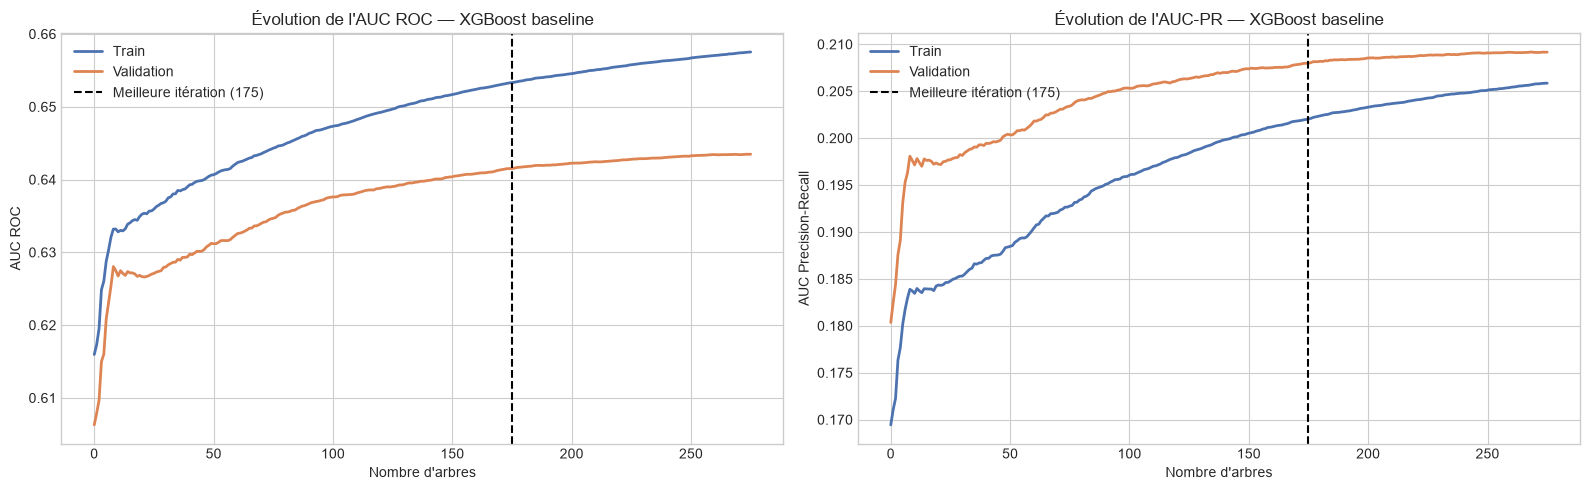

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/xgboost_baseline_learning_curves.png


In [7]:
# ============================================================
# 5. DIAGNOSTIC DE L'APPRENTISSAGE BASELINE
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5),
)

# AUC ROC.
axes[0].plot(
    historique_auc_baseline["iteration"],
    historique_auc_baseline["AUC_train"],
    label="Train",
    linewidth=2,
)

axes[0].plot(
    historique_auc_baseline["iteration"],
    historique_auc_baseline["AUC_validation"],
    label="Validation",
    linewidth=2,
)

axes[0].axvline(
    best_iteration_baseline,
    color="black",
    linestyle="--",
    label=(
        f"Meilleure itération "
        f"({best_iteration_baseline})"
    ),
)

axes[0].set_title(
    "Évolution de l'AUC ROC — XGBoost baseline"
)
axes[0].set_xlabel("Nombre d'arbres")
axes[0].set_ylabel("AUC ROC")
axes[0].legend()

# AUC Precision-Recall.
axes[1].plot(
    historique_auc_baseline["iteration"],
    historique_auc_baseline["AUC_PR_train"],
    label="Train",
    linewidth=2,
)

axes[1].plot(
    historique_auc_baseline["iteration"],
    historique_auc_baseline["AUC_PR_validation"],
    label="Validation",
    linewidth=2,
)

axes[1].axvline(
    best_iteration_baseline,
    color="black",
    linestyle="--",
    label=(
        f"Meilleure itération "
        f"({best_iteration_baseline})"
    ),
)

axes[1].set_title(
    "Évolution de l'AUC-PR — XGBoost baseline"
)
axes[1].set_xlabel("Nombre d'arbres")
axes[1].set_ylabel("AUC Precision-Recall")
axes[1].legend()

plt.tight_layout()

FIGURE_FILE = (
    OUTPUT_FIGURES_DIR
    / "xgboost_baseline_learning_curves.png"
)

plt.savefig(
    FIGURE_FILE,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {FIGURE_FILE}")


### Analyse des courbes d'apprentissage

Le modèle baseline atteint son meilleur niveau de performance sur la validation à l'itération 175. Les courbes de validation continuent de progresser jusqu'à ce point, puis stagnent, tandis que la performance sur le train continue d'augmenter.

L'écart entre train et validation est modéré. Il indique une capacité du modèle à apprendre des structures non linéaires, sans signe de surapprentissage sévère au nombre d'arbres retenu.

L'AUC-PR est plus élevée sur la validation que sur le train. Cette différence s'explique principalement par un taux de défaut supérieur dans la validation, car l'AUC-PR dépend de la prévalence de la classe défaillante.

Le modèle est donc retenu avec 175 arbres comme baseline. Le jeu de test final reste inutilisé jusqu'à la sélection définitive des hyperparamètres.


## Évaluation du baseline sur train et validation

Le modèle baseline est évalué sur le train et la validation uniquement.

Les métriques étudiées couvrent deux dimensions :
- la discrimination : AUC-ROC, Gini, AUC-PR et KS ;
- la qualité des probabilités : Brier score.

Le jeu de test 2015 reste exclu de cette étape. Il ne sera utilisé qu'après le choix définitif des hyperparamètres.


In [8]:
# ============================================================
# 6. MÉTRIQUES DU BASELINE — TRAIN ET VALIDATION
# ============================================================

def calculer_ks(y_true, probabilites):
    """
    Calcule la statistique KS maximale et le seuil associé.
    """
    fpr, tpr, seuils = roc_curve(y_true, probabilites)

    ecart_ks = tpr - fpr
    indice_ks = np.argmax(ecart_ks)

    return (
        ecart_ks[indice_ks],
        seuils[indice_ks],
        fpr[indice_ks],
        tpr[indice_ks],
    )


def calculer_metriques_classification(
    y_true,
    probabilites,
    split_name,
):
    """
    Retourne les métriques de discrimination et de calibration.
    """
    auc = roc_auc_score(y_true, probabilites)
    auc_pr = average_precision_score(y_true, probabilites)

    ks, seuil_ks, fpr_ks, tpr_ks = calculer_ks(
        y_true,
        probabilites,
    )

    return {
        "split": split_name,
        "n_prets": len(y_true),
        "taux_defaut": y_true.mean(),
        "AUC_ROC": auc,
        "Gini": 2 * auc - 1,
        "AUC_PR": auc_pr,
        "KS": ks,
        "seuil_KS": seuil_ks,
        "FPR_au_KS": fpr_ks,
        "TPR_au_KS": tpr_ks,
        "Brier": brier_score_loss(
            y_true,
            probabilites,
        ),
    }


metriques_baseline = pd.DataFrame(
    [
        calculer_metriques_classification(
            y_train,
            proba_train_xgb_baseline,
            "Train",
        ),
        calculer_metriques_classification(
            y_validation,
            proba_validation_xgb_baseline,
            "Validation",
        ),
    ]
)

# Écart train-validation : indicateur synthétique de généralisation.
ecart_auc_baseline = (
    metriques_baseline.loc[
        metriques_baseline["split"] == "Train",
        "AUC_ROC",
    ].iloc[0]
    -
    metriques_baseline.loc[
        metriques_baseline["split"] == "Validation",
        "AUC_ROC",
    ].iloc[0]
)

ecart_ks_baseline = (
    metriques_baseline.loc[
        metriques_baseline["split"] == "Train",
        "KS",
    ].iloc[0]
    -
    metriques_baseline.loc[
        metriques_baseline["split"] == "Validation",
        "KS",
    ].iloc[0]
)

print(
    f"Écart AUC train-validation : "
    f"{ecart_auc_baseline:.4f}"
)

print(
    f"Écart KS train-validation : "
    f"{ecart_ks_baseline:.4f}"
)

display(
    metriques_baseline.style.format(
        {
            "taux_defaut": "{:.2%}",
            "AUC_ROC": "{:.4f}",
            "Gini": "{:.4f}",
            "AUC_PR": "{:.4f}",
            "KS": "{:.4f}",
            "seuil_KS": "{:.4f}",
            "FPR_au_KS": "{:.2%}",
            "TPR_au_KS": "{:.2%}",
            "Brier": "{:.4f}",
        }
    )
)


Écart AUC train-validation : 0.0118
Écart KS train-validation : 0.0155


,split,n_prets,taux_defaut,AUC_ROC,Gini,AUC_PR,KS,seuil_KS,FPR_au_KS,TPR_au_KS,Brier
0,Train,172988,12.43%,0.6533,0.3066,0.2021,0.2182,0.4952,45.10%,66.92%,0.2333
1,Validation,162570,13.73%,0.6415,0.2830,0.2080,0.2027,0.5081,45.86%,66.13%,0.2440


### Analyse des métriques baseline

Le modèle XGBoost baseline présente un pouvoir discriminant satisfaisant sur la validation : AUC-ROC de 0,6415, Gini de 0,2830 et AUC-PR de
0,2080.

L'écart d'AUC entre train et validation est faible (0,0118), ce qui indique que le modèle généralise raisonnablement bien. Le KS diminue
davantage entre train et validation, de 0,2827 à 0,2027. Cette baisse reflète la dérive temporelle du portefeuille et justifie un contrôle renforcé de la stabilité après optimisation.

Le Brier score est plus élevé sur validation (0,2440). Les probabilités brutes ne doivent donc pas encore être interprétées comme des PD calibrées, notamment car la pondération `scale_pos_weight` modifie l'équilibre de la cible durant l'apprentissage.

Le baseline est retenu comme référence de départ. L'optimisation cherchera un gain de discrimination sur validation tout en maintenant un écart train-validation et une complexité maîtrisés.


## Optimisation ciblée des hyperparamètres

L'optimisation est réalisée exclusivement sur la validation temporelle de 2014. Le test final 2015 demeure entièrement réservé à l'évaluation du modèle final.

La recherche est volontairement limitée à des configurations interprétables :
- profondeur des arbres ;
- minimum d'observations par feuille ;
- sous-échantillonnage des prêts ;
- sous-échantillonnage des variables ;
- régularisation L1 et L2.

Le critère principal de sélection est l'AUC-ROC sur validation. L'AUC-PR, le KS, le Brier et l'écart train-validation restent des critères de contrôle complémentaires.


In [9]:
# ============================================================
# 7. OPTIMISATION CIBLÉE — VALIDATION UNIQUEMENT
# ============================================================

# Une grille limitée : elle teste des compromis de complexité,
# de régularisation et de sous-échantillonnage.
grille_xgboost = [
    {
        "nom_modele": "M01_baseline",
        "max_depth": 3,
        "min_child_weight": 20,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 1.00,
        "gamma": 0.00,
    },
    {
        "nom_modele": "M02_tres_regulier",
        "max_depth": 2,
        "min_child_weight": 30,
        "subsample": 0.70,
        "colsample_bytree": 0.70,
        "reg_alpha": 0.50,
        "reg_lambda": 3.00,
        "gamma": 0.10,
    },
    {
        "nom_modele": "M03_peu_profond",
        "max_depth": 2,
        "min_child_weight": 20,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 1.00,
        "gamma": 0.00,
    },
    {
        "nom_modele": "M04_profondeur_3",
        "max_depth": 3,
        "min_child_weight": 30,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.30,
        "reg_lambda": 2.00,
        "gamma": 0.00,
    },
    {
        "nom_modele": "M05_profondeur_4_regulier",
        "max_depth": 4,
        "min_child_weight": 30,
        "subsample": 0.70,
        "colsample_bytree": 0.70,
        "reg_alpha": 0.50,
        "reg_lambda": 3.00,
        "gamma": 0.10,
    },
    {
        "nom_modele": "M06_profondeur_4",
        "max_depth": 4,
        "min_child_weight": 50,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.30,
        "reg_lambda": 2.00,
        "gamma": 0.10,
    },
    {
        "nom_modele": "M07_sous_echantillonnage",
        "max_depth": 3,
        "min_child_weight": 20,
        "subsample": 0.60,
        "colsample_bytree": 0.60,
        "reg_alpha": 0.10,
        "reg_lambda": 1.00,
        "gamma": 0.00,
    },
    {
        "nom_modele": "M08_l1_forte",
        "max_depth": 3,
        "min_child_weight": 20,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 1.00,
        "reg_lambda": 1.00,
        "gamma": 0.00,
    },
    {
        "nom_modele": "M09_l2_forte",
        "max_depth": 3,
        "min_child_weight": 20,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 5.00,
        "gamma": 0.00,
    },
    {
        "nom_modele": "M10_gamma",
        "max_depth": 3,
        "min_child_weight": 20,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 1.00,
        "gamma": 0.20,
    },
]

resultats_optimisation = []
modeles_optimisation = {}

for i, params in enumerate(grille_xgboost, start=1):

    print(
        f"[{i}/{len(grille_xgboost)}] "
        f"Entraînement : {params['nom_modele']}"
    )

    xgb_candidat = XGBClassifier(
        objective="binary:logistic",
        eval_metric=["auc", "aucpr", "logloss"],
        n_estimators=1_000,
        learning_rate=0.03,
        scale_pos_weight=scale_pos_weight_train,
        early_stopping_rounds=75,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        **{
            cle: valeur
            for cle, valeur in params.items()
            if cle != "nom_modele"
        },
    )

    xgb_candidat.fit(
        X_train_prepared,
        y_train,
        eval_set=[
            (X_train_prepared, y_train),
            (X_validation_prepared, y_validation),
        ],
        verbose=False,
    )

    best_iteration = xgb_candidat.best_iteration
    best_n_estimators = best_iteration + 1

    proba_train_candidat = xgb_candidat.predict_proba(
        X_train_prepared,
        iteration_range=(0, best_n_estimators),
    )[:, 1]

    proba_validation_candidat = xgb_candidat.predict_proba(
        X_validation_prepared,
        iteration_range=(0, best_n_estimators),
    )[:, 1]

    metriques_train = calculer_metriques_classification(
        y_train,
        proba_train_candidat,
        "Train",
    )

    metriques_validation = calculer_metriques_classification(
        y_validation,
        proba_validation_candidat,
        "Validation",
    )

    resultats_optimisation.append(
        {
            **params,
            "best_iteration": best_iteration,
            "n_arbres_retenus": best_n_estimators,
            "AUC_train": metriques_train["AUC_ROC"],
            "AUC_validation": metriques_validation["AUC_ROC"],
            "ecart_AUC": (
                metriques_train["AUC_ROC"]
                - metriques_validation["AUC_ROC"]
            ),
            "AUC_PR_train": metriques_train["AUC_PR"],
            "AUC_PR_validation": (
                metriques_validation["AUC_PR"]
            ),
            "KS_train": metriques_train["KS"],
            "KS_validation": metriques_validation["KS"],
            "ecart_KS": (
                metriques_train["KS"]
                - metriques_validation["KS"]
            ),
            "Brier_train": metriques_train["Brier"],
            "Brier_validation": (
                metriques_validation["Brier"]
            ),
        }
    )

    modeles_optimisation[params["nom_modele"]] = {
        "modele": xgb_candidat,
        "proba_train": proba_train_candidat,
        "proba_validation": proba_validation_candidat,
    }

resultats_optimisation = (
    pd.DataFrame(resultats_optimisation)
    .sort_values(
        by=[
            "AUC_validation",
            "AUC_PR_validation",
            "KS_validation",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

# Rang explicite : l'AUC validation est le critère principal.
resultats_optimisation.insert(
    0,
    "rang_validation",
    np.arange(1, len(resultats_optimisation) + 1),
)

# Export : traçabilité de la sélection du modèle final.
OPTIMISATION_FILE = (
    OUTPUT_TABLES_DIR
    / "xgboost_optimisation_validation.csv"
)

resultats_optimisation.to_csv(
    OPTIMISATION_FILE,
    index=False,
)

print("\nClassement des modèles sur validation :")
display(
    resultats_optimisation.style.format(
        {
            "AUC_train": "{:.4f}",
            "AUC_validation": "{:.4f}",
            "ecart_AUC": "{:.4f}",
            "AUC_PR_train": "{:.4f}",
            "AUC_PR_validation": "{:.4f}",
            "KS_train": "{:.4f}",
            "KS_validation": "{:.4f}",
            "ecart_KS": "{:.4f}",
            "Brier_train": "{:.4f}",
            "Brier_validation": "{:.4f}",
        }
    )
)

print(f"\nTable exportée : {OPTIMISATION_FILE}")


[1/10] Entraînement : M01_baseline
[2/10] Entraînement : M02_tres_regulier
[3/10] Entraînement : M03_peu_profond
[4/10] Entraînement : M04_profondeur_3
[5/10] Entraînement : M05_profondeur_4_regulier
[6/10] Entraînement : M06_profondeur_4
[7/10] Entraînement : M07_sous_echantillonnage
[8/10] Entraînement : M08_l1_forte
[9/10] Entraînement : M09_l2_forte
[10/10] Entraînement : M10_gamma

Classement des modèles sur validation :


,rang_validation,nom_modele,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,gamma,best_iteration,n_arbres_retenus,AUC_train,AUC_validation,ecart_AUC,AUC_PR_train,AUC_PR_validation,KS_train,KS_validation,ecart_KS,Brier_train,Brier_validation
0,1,M06_profondeur_4,4,50,0.800000,0.800000,0.300000,2.000000,0.100000,157,158,0.6592,0.6441,0.0151,0.2081,0.2103,0.2278,0.2070,0.0208,0.2320,0.2431
1,2,M07_sous_echantillonnage,3,20,0.600000,0.600000,0.100000,1.000000,0.000000,200,201,0.6540,0.6427,0.0112,0.2023,0.2086,0.2212,0.2047,0.0165,0.2328,0.2435
2,3,M08_l1_forte,3,20,0.800000,0.800000,1.000000,1.000000,0.000000,200,201,0.6545,0.6423,0.0123,0.2035,0.2086,0.2199,0.2042,0.0157,0.2329,0.2440
3,4,M09_l2_forte,3,20,0.800000,0.800000,0.100000,5.000000,0.000000,200,201,0.6545,0.6422,0.0123,0.2036,0.2086,0.2197,0.2038,0.0159,0.2329,0.2439
4,5,M04_profondeur_3,3,30,0.800000,0.800000,0.300000,2.000000,0.000000,198,199,0.6544,0.6422,0.0122,0.2032,0.2087,0.2197,0.2043,0.0154,0.2330,0.2440
5,6,M03_peu_profond,2,20,0.800000,0.800000,0.100000,1.000000,0.000000,358,359,0.6525,0.6417,0.0107,0.2010,0.2077,0.2178,0.2048,0.0129,0.2331,0.2446
6,7,M01_baseline,3,20,0.800000,0.800000,0.100000,1.000000,0.000000,175,176,0.6533,0.6415,0.0118,0.2021,0.2080,0.2182,0.2027,0.0155,0.2333,0.2440
7,8,M10_gamma,3,20,0.800000,0.800000,0.100000,1.000000,0.200000,175,176,0.6533,0.6415,0.0118,0.2021,0.2080,0.2182,0.2027,0.0155,0.2333,0.2440
8,9,M05_profondeur_4_regulier,4,30,0.700000,0.700000,0.500000,3.000000,0.100000,73,74,0.6517,0.6401,0.0117,0.2003,0.2073,0.2162,0.1999,0.0163,0.2345,0.2425
9,10,M02_tres_regulier,2,30,0.700000,0.700000,0.500000,3.000000,0.100000,157,158,0.6450,0.6356,0.0094,0.1938,0.2026,0.2075,0.1952,0.0123,0.2352,0.2446



Table exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/xgboost_optimisation_validation.csv


### Sélection du modèle XGBoost final

Le modèle M06_profondeur_4 est retenu sur la validation temporelle.

Il obtient les meilleures performances parmi les dix configurations testées : AUC-ROC de 0,6441, AUC-PR de 0,2103 et KS de 0,2070. Il améliore le baseline sur les trois métriques de discrimination.

Le modèle utilise des arbres de profondeur 4, avec un minimum de 50 observations par nœud, une régularisation L1 de 0,3, une régularisation L2 de 2,0 et un gamma de 0,1. Ces contraintes limitent le risque de surapprentissage malgré une profondeur légèrement supérieure.

L'écart d'AUC entre train et validation est de 0,0151 et l'écart de KS de 0,0208. Ces écarts restent contenus, ce qui justifie la sélection du modèle pour l'évaluation finale hors échantillon.

Le test final 2015 demeure jusqu'ici totalement inutilisé. Il peut désormais être utilisé une seule fois pour évaluer M06 et le comparer formellement à la scorecard.


## Évaluation finale sur le test temporel

Attention : la pondération `scale_pos_weight` favorise la discrimination des défauts, mais les sorties brutes ne sont pas encore des PD calibrées. 
Le Brier sera donc interprété avant recalibration, puis une calibration sera étudiée dans une étape séparée.


In [10]:
# ============================================================
# 8. ÉVALUATION FINALE DE M06 — TEST 2015
# ============================================================

# Récupération du modèle sélectionné exclusivement sur validation.
NOM_MODELE_FINAL = "M06_profondeur_4"

modele_xgb_final = modeles_optimisation[
    NOM_MODELE_FINAL
]["modele"]

n_arbres_xgb_final = int(
    resultats_optimisation.loc[
        resultats_optimisation["nom_modele"] == NOM_MODELE_FINAL,
        "n_arbres_retenus",
    ].iloc[0]
)

# Le test est utilisé ici pour la première fois.
proba_test_xgb_brute = modele_xgb_final.predict_proba(
    X_test_prepared,
    iteration_range=(0, n_arbres_xgb_final),
)[:, 1]

# Métriques complètes du modèle final sur le test.
metriques_xgb_test_brut = calculer_metriques_classification(
    y_test,
    proba_test_xgb_brute,
    "Test",
)

# Table directement comparable à la scorecard.
benchmark_xgb_test_brut = pd.DataFrame(
    {
        "modèle": ["XGBoost M06 — probabilités brutes"],
        "AUC_train": [
            resultats_optimisation.loc[
                resultats_optimisation["nom_modele"]
                == NOM_MODELE_FINAL,
                "AUC_train",
            ].iloc[0]
        ],
        "AUC_validation": [
            resultats_optimisation.loc[
                resultats_optimisation["nom_modele"]
                == NOM_MODELE_FINAL,
                "AUC_validation",
            ].iloc[0]
        ],
        "AUC_test": [
            metriques_xgb_test_brut["AUC_ROC"]
        ],
        "Gini_test": [
            metriques_xgb_test_brut["Gini"]
        ],
        "KS_test": [
            metriques_xgb_test_brut["KS"]
        ],
        "Brier_test": [
            metriques_xgb_test_brut["Brier"]
        ],
        "AUC_PR_train": [
            resultats_optimisation.loc[
                resultats_optimisation["nom_modele"]
                == NOM_MODELE_FINAL,
                "AUC_PR_train",
            ].iloc[0]
        ],
        "AUC_PR_validation": [
            resultats_optimisation.loc[
                resultats_optimisation["nom_modele"]
                == NOM_MODELE_FINAL,
                "AUC_PR_validation",
            ].iloc[0]
        ],
        "AUC_PR_test": [
            metriques_xgb_test_brut["AUC_PR"]
        ],
        "taux_defaut_test": [y_test.mean()],
        "PSI_score_train_test": [np.nan],
        "PSI_variable_max": [
            benchmark_scorecard["PSI_variable_max"].iloc[0]
        ],
        "variable_PSI_max": [
            benchmark_scorecard["variable_PSI_max"].iloc[0]
        ],
        "version_probabilites": ["Brutes — non calibrées"],
    }
)

# Comparaison officielle, avant calibration.
comparaison_test_avant_calibration = pd.concat(
    [
        benchmark_scorecard,
        benchmark_xgb_test_brut,
    ],
    ignore_index=True,
)

# Différence XGBoost - Scorecard sur le test.
colonnes_comparaison = [
    "AUC_test",
    "Gini_test",
    "KS_test",
    "Brier_test",
    "AUC_PR_test",
]

ecarts_xgb_vs_scorecard = pd.DataFrame(
    {
        "métrique": colonnes_comparaison,
        "scorecard": [
            benchmark_scorecard[metric].iloc[0]
            for metric in colonnes_comparaison
        ],
        "xgboost_brut": [
            benchmark_xgb_test_brut[metric].iloc[0]
            for metric in colonnes_comparaison
        ],
    }
)

ecarts_xgb_vs_scorecard["écart_xgboost_moins_scorecard"] = (
    ecarts_xgb_vs_scorecard["xgboost_brut"]
    - ecarts_xgb_vs_scorecard["scorecard"]
)

# Export traçable du premier et unique résultat test.
TEST_BRUT_FILE = (
    OUTPUT_TABLES_DIR
    / "xgboost_m06_performance_test_brut.csv"
)

COMPARAISON_BRUTE_FILE = (
    OUTPUT_TABLES_DIR
    / "comparaison_scorecard_xgboost_avant_calibration.csv"
)

benchmark_xgb_test_brut.to_csv(
    TEST_BRUT_FILE,
    index=False,
)

comparaison_test_avant_calibration.to_csv(
    COMPARAISON_BRUTE_FILE,
    index=False,
)

print(f"Modèle évalué : {NOM_MODELE_FINAL}")
print(f"Nombre d'arbres : {n_arbres_xgb_final}")

display(
    pd.DataFrame([metriques_xgb_test_brut]).style.format(
        {
            "taux_defaut": "{:.2%}",
            "AUC_ROC": "{:.4f}",
            "Gini": "{:.4f}",
            "AUC_PR": "{:.4f}",
            "KS": "{:.4f}",
            "seuil_KS": "{:.4f}",
            "FPR_au_KS": "{:.2%}",
            "TPR_au_KS": "{:.2%}",
            "Brier": "{:.4f}",
        }
    )
)

display(
    ecarts_xgb_vs_scorecard.style.format(
        {
            "scorecard": "{:.4f}",
            "xgboost_brut": "{:.4f}",
            "écart_xgboost_moins_scorecard": "{:+.4f}",
        }
    )
)

print(f"Export XGBoost test : {TEST_BRUT_FILE}")
print(f"Export comparaison : {COMPARAISON_BRUTE_FILE}")


Modèle évalué : M06_profondeur_4
Nombre d'arbres : 158


,split,n_prets,taux_defaut,AUC_ROC,Gini,AUC_PR,KS,seuil_KS,FPR_au_KS,TPR_au_KS,Brier
0,Test,283026,14.89%,0.6421,0.2843,0.2236,0.2024,0.5010,46.87%,67.11%,0.2420


,métrique,scorecard,xgboost_brut,écart_xgboost_moins_scorecard
0,AUC_test,0.6300,0.6421,+0.0121
1,Gini_test,0.2600,0.2843,+0.0243
2,KS_test,0.1885,0.2024,+0.0139
3,Brier_test,0.1238,0.2420,+0.1181
4,AUC_PR_test,0.2126,0.2236,+0.0110


Export XGBoost test : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/xgboost_m06_performance_test_brut.csv
Export comparaison : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/comparaison_scorecard_xgboost_avant_calibration.csv


## Recalibration des probabilités XGBoost

La pondération `scale_pos_weight` a permis d'améliorer la détection et le classement des défauts, mais elle a déformé les probabilités brutes produites par XGBoost.

Une calibration sigmoïde, aussi appelée Platt scaling, est ajustée sur la validation 2014. Elle apprend une fonction monotone qui convertit les scores bruts en probabilités de défaut calibrées.

La calibration ne modifie pas substantiellement le ranking : AUC, Gini, AUC-PR et KS doivent donc rester presque identiques. Elle vise avant tout à améliorer la qualité des PD, mesurée par le Brier score et les courbes de calibration.

Le test 2015 sert uniquement à mesurer, une seule fois, la qualité des probabilités recalibrées.


In [11]:
# ============================================================
# 9. RECALIBRATION SIGMOÏDE — PLATT SCALING
# ============================================================

# La calibration est ajustée sur validation uniquement.
# reshape(-1, 1) est nécessaire car LogisticRegression attend
# une matrice à une colonne, contenant les scores XGBoost bruts.
calibrateur_platt = LogisticRegression(
    solver="lbfgs",
    C=1_000_000,
    max_iter=1_000,
    random_state=RANDOM_STATE,
)

calibrateur_platt.fit(
    proba_validation_candidat.reshape(-1, 1)
    if False
    else modeles_optimisation[NOM_MODELE_FINAL][
        "proba_validation"
    ].reshape(-1, 1),
    y_validation,
)

# Probabilités calibrées sur les trois jeux.
proba_train_xgb_calibree = calibrateur_platt.predict_proba(
    modeles_optimisation[NOM_MODELE_FINAL][
        "proba_train"
    ].reshape(-1, 1)
)[:, 1]

proba_validation_xgb_calibree = (
    calibrateur_platt.predict_proba(
        modeles_optimisation[NOM_MODELE_FINAL][
            "proba_validation"
        ].reshape(-1, 1)
    )[:, 1]
)

proba_test_xgb_calibree = calibrateur_platt.predict_proba(
    proba_test_xgb_brute.reshape(-1, 1)
)[:, 1]

# Évaluation sur validation et test.
metriques_xgb_validation_calibree = (
    calculer_metriques_classification(
        y_validation,
        proba_validation_xgb_calibree,
        "Validation calibrée",
    )
)

metriques_xgb_test_calibree = (
    calculer_metriques_classification(
        y_test,
        proba_test_xgb_calibree,
        "Test calibré",
    )
)

# Comparaison avant / après calibration.
comparaison_calibration_xgb = pd.DataFrame(
    [
        {
            "version": "XGBoost brut",
            "split": "Validation",
            **calculer_metriques_classification(
                y_validation,
                modeles_optimisation[NOM_MODELE_FINAL][
                    "proba_validation"
                ],
                "Validation",
            ),
        },
        {
            "version": "XGBoost calibré",
            "split": "Validation",
            **metriques_xgb_validation_calibree,
        },
        {
            "version": "XGBoost brut",
            "split": "Test",
            **metriques_xgb_test_brut,
        },
        {
            "version": "XGBoost calibré",
            "split": "Test",
            **metriques_xgb_test_calibree,
        },
    ]
)

# Retirer la colonne split redondante créée par la fonction.
comparaison_calibration_xgb = comparaison_calibration_xgb.loc[
    :,
    ~comparaison_calibration_xgb.columns.duplicated(),
]

CALIBRATION_RESULTS_FILE = (
    OUTPUT_TABLES_DIR
    / "xgboost_m06_comparaison_calibration.csv"
)

comparaison_calibration_xgb.to_csv(
    CALIBRATION_RESULTS_FILE,
    index=False,
)

display(
    comparaison_calibration_xgb[
        [
            "version",
            "split",
            "AUC_ROC",
            "Gini",
            "AUC_PR",
            "KS",
            "Brier",
        ]
    ].style.format(
        {
            "AUC_ROC": "{:.4f}",
            "Gini": "{:.4f}",
            "AUC_PR": "{:.4f}",
            "KS": "{:.4f}",
            "Brier": "{:.4f}",
        }
    )
)

print(
    "Brier test brut : "
    f"{metriques_xgb_test_brut['Brier']:.4f}"
)
print(
    "Brier test calibré : "
    f"{metriques_xgb_test_calibree['Brier']:.4f}"
)
print(
    "Amélioration du Brier : "
    f"{metriques_xgb_test_brut['Brier'] - metriques_xgb_test_calibree['Brier']:.4f}"
)
print(f"\nTable exportée : {CALIBRATION_RESULTS_FILE}")


,version,split,AUC_ROC,Gini,AUC_PR,KS,Brier
0,XGBoost brut,Validation,0.6441,0.2883,0.2103,0.2070,0.2431
1,XGBoost calibré,Validation calibrée,0.6441,0.2883,0.2103,0.2070,0.1148
2,XGBoost brut,Test,0.6421,0.2843,0.2236,0.2024,0.2420
3,XGBoost calibré,Test calibré,0.6421,0.2843,0.2236,0.2024,0.1229


Brier test brut : 0.2420
Brier test calibré : 0.1229
Amélioration du Brier : 0.1191

Table exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/xgboost_m06_comparaison_calibration.csv


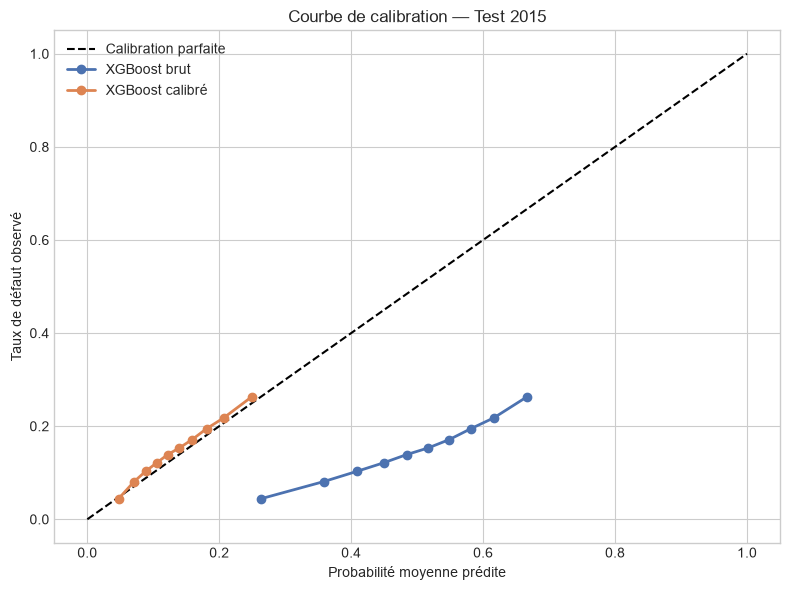

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/xgboost_m06_courbe_calibration_test.png


In [12]:
# ============================================================
# 10. COURBES DE CALIBRATION — XGBOOST BRUT VS CALIBRÉ
# ============================================================

nb_bins_calibration = 10

taux_observe_brut, proba_moyenne_brute = calibration_curve(
    y_test,
    proba_test_xgb_brute,
    n_bins=nb_bins_calibration,
    strategy="quantile",
)

taux_observe_calibre, proba_moyenne_calibree = calibration_curve(
    y_test,
    proba_test_xgb_calibree,
    n_bins=nb_bins_calibration,
    strategy="quantile",
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Calibration parfaite",
)

ax.plot(
    proba_moyenne_brute,
    taux_observe_brut,
    marker="o",
    linewidth=2,
    label="XGBoost brut",
)

ax.plot(
    proba_moyenne_calibree,
    taux_observe_calibre,
    marker="o",
    linewidth=2,
    label="XGBoost calibré",
)

ax.set_title(
    "Courbe de calibration — Test 2015"
)
ax.set_xlabel("Probabilité moyenne prédite")
ax.set_ylabel("Taux de défaut observé")
ax.legend()

plt.tight_layout()

CALIBRATION_FIGURE_FILE = (
    OUTPUT_FIGURES_DIR
    / "xgboost_m06_courbe_calibration_test.png"
)

plt.savefig(
    CALIBRATION_FIGURE_FILE,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {CALIBRATION_FIGURE_FILE}")


### Analyse de la recalibration

La calibration sigmoïde réduit fortement le Brier score de XGBoost sur le test final, de 0,2420 à 0,1229. Les probabilités recalibrées sont donc beaucoup plus proches des taux de défaut effectivement observés.

L'AUC-ROC, le Gini, l'AUC-PR et le KS restent identiques avant et après calibration. C'est le comportement attendu : la calibration corrige l'échelle des probabilités sans modifier l'ordre de risque des prêts.

Après recalibration, XGBoost dépasse la scorecard à la fois sur la discrimination et très légèrement sur le Brier test. Il est donc le meilleur modèle prédictif du projet, sous réserve de confirmer sa stabilité et son interprétabilité.


La courbe test 2015 doit montrer un écart très net entre les probabilités brutes et recalibrées : XGBoost brut surestime fortement le niveau absolu de risque, tandis que la courbe recalibrée revient près de la diagonale de calibration parfaite. Cela est cohérent avec la chute du Brier de 0,2420 à 0,1229.

XGBoost brut
La courbe brute devrait se situer majoritairement sous la diagonale : pour une probabilité prédite donnée, le taux de défaut observé est inférieur. Par exemple, lorsqu’un score brut indique un risque élevé, le taux de défaut réalisé est plus faible que cette valeur prédite.
Cela confirme que les sorties brutes ne peuvent pas être interprétées comme des PD. Elles restent néanmoins utiles pour ordonner les prêts par niveau de risque, ce que confirment l’AUC de 0,6421 et le KS de 0,2024.

XGBoost recalibré
La courbe recalibrée doit être beaucoup plus proche de la diagonale : dans chaque segment de risque, la PD moyenne prédite est alors proche du taux de défaut réellement observé.
Le résultat quantitatif est très fort : le Brier test passe à 0,1229, sous la scorecard à 0,1238. La calibration corrige donc l’échelle des PD sans sacrifier le classement : AUC, Gini, AUC-PR et KS sont identiques avant et après à l’arrondi près.

Nuance importante
Une légère oscillation des derniers points n’est pas préoccupante. Les déciles de risque extrêmes contiennent des profils rares et hétérogènes ; l’estimation du taux de défaut observé y est naturellement plus variable.

## Bandes de risque XGBoost

Les probabilités calibrées sont transformées en cinq bandes de risque, définies à partir des quantiles de la validation 2014.

Les seuils sont fixés avant l'évaluation test, afin d'éviter d'adapter artificiellement les catégories au portefeuille 2015.

La bande 1 correspond aux prêts dont la PD est la plus élevée, donc au risque le plus fort. La bande 5 correspond au risque le plus faible.

Pour chaque bande, nous comparons le taux de défaut observé à la PD moyenne prédite et calculons le lift par rapport au taux de défaut global du test.


In [13]:
# ============================================================
# 11. BANDES DE RISQUE — XGBOOST CALIBRÉ
# ============================================================

# Seuils définis uniquement sur la validation temporelle.
seuils_bandes_xgb = np.unique(
    np.quantile(
        proba_validation_xgb_calibree,
        q=[0.00, 0.20, 0.40, 0.60, 0.80, 1.00],
    )
)

labels_bandes_xgb = [
    "1 - Très faible risque",
    "2 - Faible risque",
    "3 - Intermédiaire",
    "4 - Risqué",
    "5 - Très risqué",
]

assert len(seuils_bandes_xgb) == (
    len(labels_bandes_xgb) + 1
), (
    "Les seuils ne permettent pas de créer "
    "cinq bandes distinctes."
)

# Évaluation sur le test final : aucune redéfinition des seuils.
analyse_bandes_xgb_test = pd.DataFrame(
    {
        "pd_calibree": proba_test_xgb_calibree,
        "default_flag": y_test.to_numpy(),
    }
)

analyse_bandes_xgb_test["bande_risque"] = pd.cut(
    analyse_bandes_xgb_test["pd_calibree"],
    bins=seuils_bandes_xgb,
    labels=labels_bandes_xgb,
    include_lowest=True,
)

performance_bandes_xgb_test = (
    analyse_bandes_xgb_test
    .groupby("bande_risque", observed=False)
    .agg(
        pd_min=("pd_calibree", "min"),
        pd_max=("pd_calibree", "max"),
        n_prets=("default_flag", "size"),
        n_defauts=("default_flag", "sum"),
        taux_defaut_observe=("default_flag", "mean"),
        pd_moyenne_predite=("pd_calibree", "mean"),
    )
    .reset_index()
)

performance_bandes_xgb_test["part_portefeuille"] = (
    performance_bandes_xgb_test["n_prets"]
    / performance_bandes_xgb_test["n_prets"].sum()
)

performance_bandes_xgb_test["lift_vs_portefeuille"] = (
    performance_bandes_xgb_test["taux_defaut_observe"]
    / y_test.mean()
)

BANDES_XGB_FILE = (
    OUTPUT_TABLES_DIR
    / "xgboost_m06_bandes_risque_test.csv"
)

performance_bandes_xgb_test.to_csv(
    BANDES_XGB_FILE,
    index=False,
)

display(
    performance_bandes_xgb_test.style.format(
        {
            "pd_min": "{:.2%}",
            "pd_max": "{:.2%}",
            "taux_defaut_observe": "{:.2%}",
            "pd_moyenne_predite": "{:.2%}",
            "part_portefeuille": "{:.2%}",
            "lift_vs_portefeuille": "{:.2f}x",
        }
    )
)

print(f"Table exportée : {BANDES_XGB_FILE}")


,bande_risque,pd_min,pd_max,n_prets,n_defauts,taux_defaut_observe,pd_moyenne_predite,part_portefeuille,lift_vs_portefeuille
0,1 - Très faible risque,2.06%,8.04%,57149,3600,6.30%,5.94%,20.19%,0.42x
1,2 - Faible risque,8.04%,11.40%,57026,6434,11.28%,9.72%,20.15%,0.76x
2,3 - Intermédiaire,11.40%,14.97%,56826,8325,14.65%,13.14%,20.08%,0.98x
3,4 - Risqué,14.97%,19.31%,55749,10228,18.35%,17.04%,19.70%,1.23x
4,5 - Très risqué,19.31%,36.92%,56271,13544,24.07%,22.82%,19.88%,1.62x


Table exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/xgboost_m06_bandes_risque_test.csv


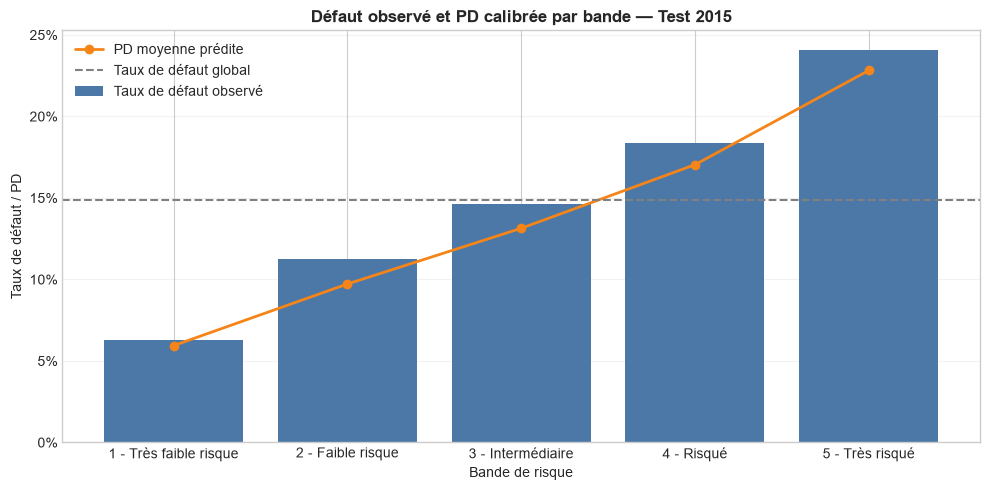

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/xgboost_m06_bandes_risque_test.png


In [14]:
# ============================================================
# 12. VISUALISATION DES BANDES DE RISQUE — TEST 2015
# ============================================================

performance_bandes_xgb_plot = (
    performance_bandes_xgb_test
    .copy()
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    performance_bandes_xgb_plot["bande_risque"],
    performance_bandes_xgb_plot["taux_defaut_observe"],
    color="#4C78A8",
    label="Taux de défaut observé",
)

ax.plot(
    performance_bandes_xgb_plot["bande_risque"],
    performance_bandes_xgb_plot["pd_moyenne_predite"],
    color="#F58518",
    marker="o",
    linewidth=2,
    label="PD moyenne prédite",
)

ax.axhline(
    y=y_test.mean(),
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Taux de défaut global",
)

ax.set_title(
    "Défaut observé et PD calibrée par bande — Test 2015",
    fontweight="bold",
)

ax.set_xlabel("Bande de risque")
ax.set_ylabel("Taux de défaut / PD")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda valeur, _: f"{valeur:.0%}")
)

ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

BANDES_XGB_FIGURE_FILE = (
    OUTPUT_FIGURES_DIR
    / "xgboost_m06_bandes_risque_test.png"
)

plt.savefig(
    BANDES_XGB_FIGURE_FILE,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure exportée : {BANDES_XGB_FIGURE_FILE}"
)


Discrimination métier
Le défaut observé augmente sans inversion entre les cinq bandes : de 6,30% à 24,07%, soit un facteur de 3,82 entre les segments extrêmes. La bande la plus risquée concentre 13 544 défauts pour environ 19,9% du portefeuille, alors que la bande la plus sûre n’en comporte que 3 600 pour une taille comparable.
Les proportions de prêts par bande restent proches de 20%, ce qui est rassurant : les seuils ont été fixés sur validation puis appliqués au test sans que la distribution se déséquilibre fortement.

Calibration par bande
Les PD moyennes sous-estiment légèrement le défaut réalisé dans chaque bande, particulièrement dans les bandes 2 à 5 : par exemple, 22,82% prédits contre 24,07% observés dans le segment très risqué.
Cette sous-estimation régulière indique une légère évolution défavorable du portefeuille 2015 par rapport à la validation 2014. Elle reste modérée, et le Brier test faible à 0,1229 confirme que les probabilités sont globalement bien calibrées.


Usage opérationnel
•	Bandes 1–2 : acceptation plus fluide, sous réserve des règles d’éligibilité indépendantes du modèle.
•	Bande 3 : tarification ou conditions standard, avec suivi normal.
•	Bande 4 : revue renforcée, limites de montant ou conditions plus strictes.
•	Bande 5 : revue manuelle prioritaire, exigence de garanties supplémentaires ou refus selon l’appétit au risque.


## Interprétabilité : importance par permutation

L'importance par permutation mesure la baisse de performance observée lorsqu'une variable est mélangée aléatoirement.

Une forte baisse d'AUC signifie que le modèle s'appuie fortement sur cette variable pour classer le risque. L'analyse est réalisée sur le test final et sur les neuf variables métier d'origine, et non sur les 27 colonnes créées par l'encodage one-hot.

Les importances décrivent la contribution prédictive au modèle ; elles ne démontrent pas une relation causale avec le défaut.

In [15]:
# ============================================================
# 13. IMPORTANCE PAR PERMUTATION — XGBOOST CALIBRÉ
# ============================================================

# La calibration est monotone : elle ne change pas l'AUC.
# L'importance peut donc être calculée à partir du modèle brut.
#
# Nous utilisons les 9 variables métier AVANT encodage, afin de
# restituer une lecture claire au niveau des variables d'origine.

def predict_proba_xgb_pipeline(X_raw):
    """
    Transforme les variables brutes puis renvoie la PD XGBoost calibrée.
    """
    X_prepared = preprocesseur_xgboost.transform(X_raw)

    proba_brute = modele_xgb_final.predict_proba(
        X_prepared,
        iteration_range=(0, n_arbres_xgb_final),
    )[:, 1]

    return calibrateur_platt.predict_proba(
        proba_brute.reshape(-1, 1)
    )[:, 1]


def importance_permutation_auc(
    X_raw,
    y_true,
    n_repetitions=5,
    random_state=RANDOM_STATE,
):
    """
    Calcule la baisse d'AUC après permutation de chaque variable.
    """
    rng = np.random.default_rng(random_state)

    auc_reference = roc_auc_score(
        y_true,
        predict_proba_xgb_pipeline(X_raw),
    )

    resultats = []

    for variable in FEATURES_V1:
        pertes_auc = []

        for _ in range(n_repetitions):
            X_permute = X_raw.copy()

            X_permute[variable] = rng.permutation(
                X_permute[variable].to_numpy()
            )

            auc_permutee = roc_auc_score(
                y_true,
                predict_proba_xgb_pipeline(X_permute),
            )

            pertes_auc.append(
                auc_reference - auc_permutee
            )

        resultats.append(
            {
                "variable": variable,
                "AUC_reference": auc_reference,
                "baisse_AUC_moyenne": np.mean(pertes_auc),
                "baisse_AUC_ecart_type": np.std(
                    pertes_auc,
                    ddof=1,
                ),
                "baisse_AUC_min": np.min(pertes_auc),
                "baisse_AUC_max": np.max(pertes_auc),
            }
        )

    return (
        pd.DataFrame(resultats)
        .sort_values(
            "baisse_AUC_moyenne",
            ascending=False,
        )
        .reset_index(drop=True)
    )


# L’analyse porte sur le test final, sans réentraînement du modèle.
importance_permutation_xgb = importance_permutation_auc(
    X_raw=X_test.loc[:, FEATURES_V1],
    y_true=y_test,
    n_repetitions=5,
)

IMPORTANCE_PERMUTATION_FILE = (
    OUTPUT_TABLES_DIR
    / "xgboost_m06_importance_permutation_test.csv"
)

importance_permutation_xgb.to_csv(
    IMPORTANCE_PERMUTATION_FILE,
    index=False,
)

display(
    importance_permutation_xgb.style.format(
        {
            "AUC_reference": "{:.4f}",
            "baisse_AUC_moyenne": "{:.4f}",
            "baisse_AUC_ecart_type": "{:.4f}",
            "baisse_AUC_min": "{:.4f}",
            "baisse_AUC_max": "{:.4f}",
        }
    )
)

print(f"Table exportée : {IMPORTANCE_PERMUTATION_FILE}")


,variable,AUC_reference,baisse_AUC_moyenne,baisse_AUC_ecart_type,baisse_AUC_min,baisse_AUC_max
0,fico_score,0.6421,0.0644,0.0008,0.0630,0.0652
1,annual_inc,0.6421,0.0361,0.0011,0.0342,0.0371
2,dti,0.6421,0.0137,0.0003,0.0134,0.0142
3,purpose,0.6421,0.0112,0.0003,0.0109,0.0118
4,loan_amnt,0.6421,0.0104,0.0002,0.0100,0.0106
5,home_ownership,0.6421,0.0041,0.0000,0.0040,0.0041
6,credit_history_months,0.6421,0.0024,0.0001,0.0023,0.0025
7,revol_util,0.6421,0.0006,0.0002,0.0003,0.0009
8,verification_status,0.6421,0.0004,0.0000,0.0003,0.0004


Table exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/xgboost_m06_importance_permutation_test.csv


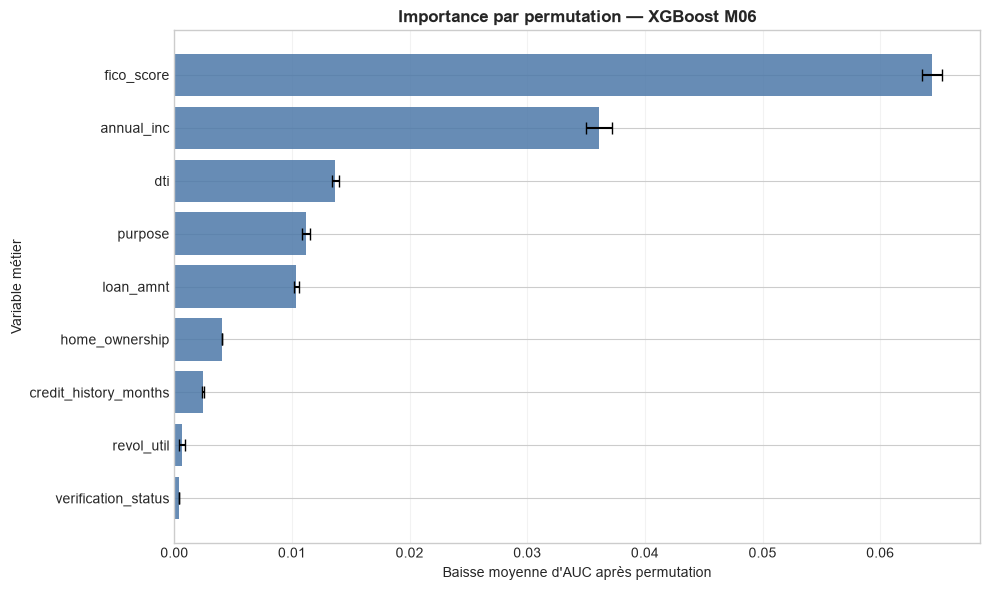

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/xgboost_m06_importance_permutation_test.png


In [16]:
# ============================================================
# 14. VISUALISATION DES IMPORTANCES — XGBOOST M06
# ============================================================

importance_plot = (
    importance_permutation_xgb
    .sort_values("baisse_AUC_moyenne")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    importance_plot["variable"],
    importance_plot["baisse_AUC_moyenne"],
    xerr=importance_plot["baisse_AUC_ecart_type"],
    color="#4C78A8",
    alpha=0.85,
    capsize=4,
)

ax.set_title(
    "Importance par permutation — XGBoost M06",
    fontweight="bold",
)

ax.set_xlabel(
    "Baisse moyenne d'AUC après permutation"
)

ax.set_ylabel("Variable métier")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()

IMPORTANCE_FIGURE_FILE = (
    OUTPUT_FIGURES_DIR
    / "xgboost_m06_importance_permutation_test.png"
)

plt.savefig(
    IMPORTANCE_FIGURE_FILE,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {IMPORTANCE_FIGURE_FILE}")


### Analyse des importances par permutation

Le `fico_score` est de loin la variable la plus importante : sa permutation réduit l'AUC de 0,0644 en moyenne. `annual_inc` est la seconde variable la plus contributive, avec une baisse d'AUC de 0,0361.

Le modèle s'appuie ensuite sur le taux d'endettement (`dti`), l'objet du prêt (`purpose`) et le montant emprunté (`loan_amnt`). Cette hiérarchie est cohérente avec une logique de risque crédit: historique de crédit, capacité financière, endettement et caractéristiques du financement.

`revol_util` et `verification_status` apportent peu d'information additionnelle une fois les autres variables connues. Elles sont néanmoins conservées dans la V1, car leur faible contribution ne prouve pas leur inutilité dans d'autres périodes ou sous-populations.

Les faibles écarts-types observés sur les permutations confirment que la hiérarchie des variables est stable.




## Stabilité temporelle du score XGBoost

Le Population Stability Index (PSI) mesure l'évolution de la distribution des PD prédites entre deux périodes.

Les seuils de découpage sont définis sur les scores train, puis appliqués sans modification à la validation et au test.

Repères d'interprétation :
- PSI inférieur à 0,10 : distribution stable ;
- PSI entre 0,10 et 0,25 : dérive modérée à surveiller ;
- PSI supérieur ou égal à 0,25 : dérive forte nécessitant une action.

Le PSI mesure une dérive de la distribution des scores. Il ne mesure ni la discrimination ni la calibration ; il complète donc AUC, KS et Brier.


In [17]:
# ============================================================
# 15. PSI DES PD XGBOOST — TRAIN / VALIDATION / TEST
# ============================================================

def calculer_psi(
    valeurs_reference,
    valeurs_comparees,
    n_buckets=10,
    epsilon=1e-6,
):
    """
    Calcule le PSI à partir de déciles définis sur la référence.
    """
    valeurs_reference = np.asarray(valeurs_reference)
    valeurs_comparees = np.asarray(valeurs_comparees)

    bornes = np.unique(
        np.quantile(
            valeurs_reference,
            q=np.linspace(0, 1, n_buckets + 1),
        )
    )

    assert len(bornes) > 2, (
        "Les scores de référence ne permettent pas "
        "de créer suffisamment de buckets."
    )

    # Évite que les valeurs extrêmes comparées sortent des buckets.
    bornes[0] = -np.inf
    bornes[-1] = np.inf

    reference_buckets = pd.cut(
        valeurs_reference,
        bins=bornes,
        include_lowest=True,
    )

    compare_buckets = pd.cut(
        valeurs_comparees,
        bins=bornes,
        include_lowest=True,
    )

    distribution_reference = (
        pd.Series(reference_buckets)
        .value_counts(normalize=True, sort=False)
    )

    distribution_comparee = (
        pd.Series(compare_buckets)
        .value_counts(normalize=True, sort=False)
    )

    detail_psi = pd.DataFrame(
        {
            "bucket": distribution_reference.index.astype(str),
            "part_reference": distribution_reference.values,
            "part_comparee": distribution_comparee.values,
        }
    )

    detail_psi["part_reference"] = (
        detail_psi["part_reference"].clip(lower=epsilon)
    )

    detail_psi["part_comparee"] = (
        detail_psi["part_comparee"].clip(lower=epsilon)
    )

    detail_psi["contribution_psi"] = (
        (
            detail_psi["part_reference"]
            - detail_psi["part_comparee"]
        )
        * np.log(
            detail_psi["part_reference"]
            / detail_psi["part_comparee"]
        )
    )

    psi_total = detail_psi["contribution_psi"].sum()

    return psi_total, detail_psi


def interpreter_psi(psi):
    if psi < 0.10:
        return "Stable"
    if psi < 0.25:
        return "Dérive modérée"
    return "Dérive forte"


# PD calibrées sur les trois périodes.
psi_train_validation, detail_psi_train_validation = calculer_psi(
    proba_train_xgb_calibree,
    proba_validation_xgb_calibree,
)

psi_train_test, detail_psi_train_test = calculer_psi(
    proba_train_xgb_calibree,
    proba_test_xgb_calibree,
)

resume_psi_xgb = pd.DataFrame(
    {
        "comparaison": [
            "Train vs Validation",
            "Train vs Test",
        ],
        "PSI_score": [
            psi_train_validation,
            psi_train_test,
        ],
        "interprétation": [
            interpreter_psi(psi_train_validation),
            interpreter_psi(psi_train_test),
        ],
    }
)

detail_psi_xgb = pd.concat(
    [
        detail_psi_train_validation.assign(
            comparaison="Train vs Validation"
        ),
        detail_psi_train_test.assign(
            comparaison="Train vs Test"
        ),
    ],
    ignore_index=True,
)

PSI_XGB_FILE = (
    OUTPUT_TABLES_DIR
    / "xgboost_m06_psi_scores.csv"
)

PSI_XGB_DETAIL_FILE = (
    OUTPUT_TABLES_DIR
    / "xgboost_m06_psi_scores_detail.csv"
)

resume_psi_xgb.to_csv(
    PSI_XGB_FILE,
    index=False,
)

detail_psi_xgb.to_csv(
    PSI_XGB_DETAIL_FILE,
    index=False,
)

display(
    resume_psi_xgb.style.format(
        {"PSI_score": "{:.4f}"}
    )
)

print(f"Synthèse PSI exportée : {PSI_XGB_FILE}")
print(f"Détail PSI exporté : {PSI_XGB_DETAIL_FILE}")


,comparaison,PSI_score,interprétation
0,Train vs Validation,0.0163,Stable
1,Train vs Test,0.0146,Stable


Synthèse PSI exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/xgboost_m06_psi_scores.csv
Détail PSI exporté : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/xgboost_m06_psi_scores_detail.csv


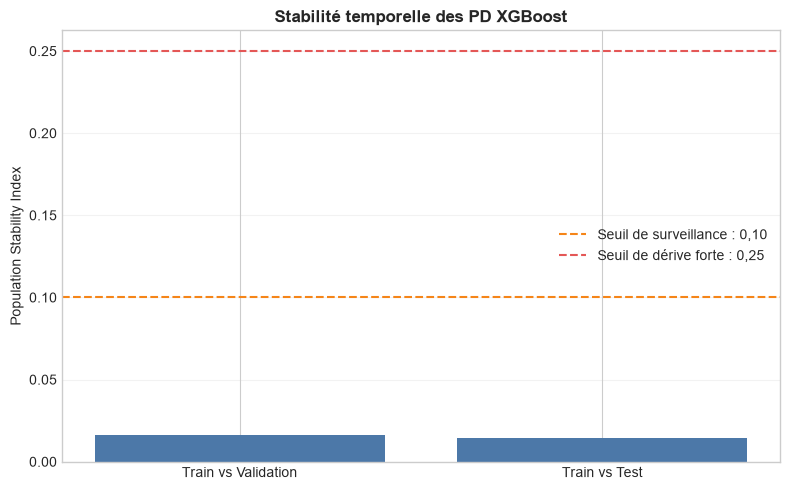

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/xgboost_m06_psi_scores.png


In [18]:
# ============================================================
# 16. VISUALISATION DU PSI DES PD XGBOOST
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

couleurs_psi = [
    "#4C78A8"
    if valeur < 0.10
    else "#F58518"
    if valeur < 0.25
    else "#E45756"
    for valeur in resume_psi_xgb["PSI_score"]
]

ax.bar(
    resume_psi_xgb["comparaison"],
    resume_psi_xgb["PSI_score"],
    color=couleurs_psi,
)

ax.axhline(
    y=0.10,
    color="#F58518",
    linestyle="--",
    linewidth=1.5,
    label="Seuil de surveillance : 0,10",
)

ax.axhline(
    y=0.25,
    color="#E45756",
    linestyle="--",
    linewidth=1.5,
    label="Seuil de dérive forte : 0,25",
)

ax.set_title(
    "Stabilité temporelle des PD XGBoost",
    fontweight="bold",
)

ax.set_ylabel("Population Stability Index")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

PSI_XGB_FIGURE_FILE = (
    OUTPUT_FIGURES_DIR
    / "xgboost_m06_psi_scores.png"
)

plt.savefig(
    PSI_XGB_FIGURE_FILE,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure exportée : {PSI_XGB_FIGURE_FILE}"
)


### Analyse de la stabilité temporelle

Les PD XGBoost recalibrées présentent une excellente stabilité temporelle. Le PSI est de 0,0163 entre train et validation et de
0,0146 entre train et test, largement sous le seuil de surveillance de 0,10.

La répartition des PD se décale légèrement vers les segments de risque élevé dans les périodes futures. Cette évolution est cohérente avec la hausse du taux de défaut observé entre train et test.

La dérive reste toutefois faible et comparable à celle de la scorecard. Elle ne remet pas en cause la robustesse temporelle du modèle XGBoost.


## Comparaison finale : scorecard vs XGBoost

La comparaison finale porte sur le test temporel 2015 commun aux deux modèles.

XGBoost est évalué à partir des PD recalibrées par Platt scaling. La scorecard utilise sa version de probabilités retenue dans le notebook précédent.

La décision métier oppose donc l'interprétabilité et la simplicité de la scorecard à la performance prédictive de XGBoost.


In [19]:
# ============================================================
# 17. COMPARAISON FINALE — SCORECARD VS XGBOOST CALIBRÉ
# ============================================================

psi_xgb_train_test = resume_psi_xgb.loc[
    resume_psi_xgb["comparaison"] == "Train vs Test",
    "PSI_score",
].iloc[0]

# XGBoost avec les PD recalibrées.
benchmark_xgb_final = pd.DataFrame(
    {
        "modèle": ["XGBoost M06 — PD recalibrées"],
        "AUC_test": [
            metriques_xgb_test_calibree["AUC_ROC"]
        ],
        "Gini_test": [
            metriques_xgb_test_calibree["Gini"]
        ],
        "KS_test": [
            metriques_xgb_test_calibree["KS"]
        ],
        "AUC_PR_test": [
            metriques_xgb_test_calibree["AUC_PR"]
        ],
        "Brier_test": [
            metriques_xgb_test_calibree["Brier"]
        ],
        "PSI_score_train_test": [
            psi_xgb_train_test
        ],
        "version_probabilites": [
            "Platt scaling sur validation 2014"
        ],
    }
)

colonnes_metriques = [
    "AUC_test",
    "Gini_test",
    "KS_test",
    "AUC_PR_test",
    "Brier_test",
    "PSI_score_train_test",
]

# Scorecard : mêmes métriques, même test temporel.
benchmark_scorecard_final = benchmark_scorecard[
    [
        "modèle",
        *colonnes_metriques,
        "version_probabilites",
    ]
].copy()

comparaison_finale_modeles = pd.concat(
    [
        benchmark_scorecard_final,
        benchmark_xgb_final,
    ],
    ignore_index=True,
)

# Écarts signés : positif favorise XGBoost pour les métriques
# de discrimination ; négatif favorise XGBoost pour Brier et PSI.
synthese_gain_xgb = pd.DataFrame(
    {
        "métrique": [
            "AUC",
            "Gini",
            "KS",
            "AUC-PR",
            "Brier",
            "PSI",
        ],
        "scorecard": [
            benchmark_scorecard_final[colonne].iloc[0]
            for colonne in colonnes_metriques
        ],
        "xgboost_calibré": [
            benchmark_xgb_final[colonne].iloc[0]
            for colonne in colonnes_metriques
        ],
    }
)

synthese_gain_xgb["écart_xgboost_moins_scorecard"] = (
    synthese_gain_xgb["xgboost_calibré"]
    - synthese_gain_xgb["scorecard"]
)

COMPARAISON_FINALE_FILE = (
    OUTPUT_TABLES_DIR
    / "comparaison_finale_scorecard_xgboost.csv"
)

GAIN_XGB_FILE = (
    OUTPUT_TABLES_DIR
    / "synthese_gains_xgboost_vs_scorecard.csv"
)

comparaison_finale_modeles.to_csv(
    COMPARAISON_FINALE_FILE,
    index=False,
)

synthese_gain_xgb.to_csv(
    GAIN_XGB_FILE,
    index=False,
)

display(
    comparaison_finale_modeles.style.format(
        {
            "AUC_test": "{:.4f}",
            "Gini_test": "{:.4f}",
            "KS_test": "{:.4f}",
            "AUC_PR_test": "{:.4f}",
            "Brier_test": "{:.4f}",
            "PSI_score_train_test": "{:.4f}",
        }
    )
)

display(
    synthese_gain_xgb.style.format(
        {
            "scorecard": "{:.4f}",
            "xgboost_calibré": "{:.4f}",
            "écart_xgboost_moins_scorecard": "{:+.4f}",
        }
    )
)

print(
    f"Comparaison finale exportée : "
    f"{COMPARAISON_FINALE_FILE}"
)

print(
    f"Synthèse des gains exportée : "
    f"{GAIN_XGB_FILE}"
)


,modèle,AUC_test,Gini_test,KS_test,AUC_PR_test,Brier_test,PSI_score_train_test,version_probabilites
0,Scorecard logistique WoE V1,0.6300,0.2600,0.1885,0.2126,0.1238,0.0131,Initiale
1,XGBoost M06 — PD recalibrées,0.6421,0.2843,0.2024,0.2236,0.1229,0.0146,Platt scaling sur validation 2014


,métrique,scorecard,xgboost_calibré,écart_xgboost_moins_scorecard
0,AUC,0.6300,0.6421,+0.0121
1,Gini,0.2600,0.2843,+0.0243
2,KS,0.1885,0.2024,+0.0139
3,AUC-PR,0.2126,0.2236,+0.0110
4,Brier,0.1238,0.1229,-0.0009
5,PSI,0.0131,0.0146,+0.0015


Comparaison finale exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/comparaison_finale_scorecard_xgboost.csv
Synthèse des gains exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/synthese_gains_xgboost_vs_scorecard.csv


La comparaison finale confirme que XGBoost M06 recalibré est le meilleur modèle prédictif : il améliore l’AUC de 0,0121, le Gini de 0,0243, le KS de 0,0139 et l’AUC-PR de 0,0110 par rapport à la scorecard. Son Brier est aussi légèrement meilleur, tandis que son PSI reste très faible et comparable à celui de la scorecard.
Le gain reste modéré mais systématique sur chaque métrique utile. XGBoost doit donc être retenu comme modèle de performance, tandis que la scorecard reste un excellent challenger interprétable et un support de gouvernance.

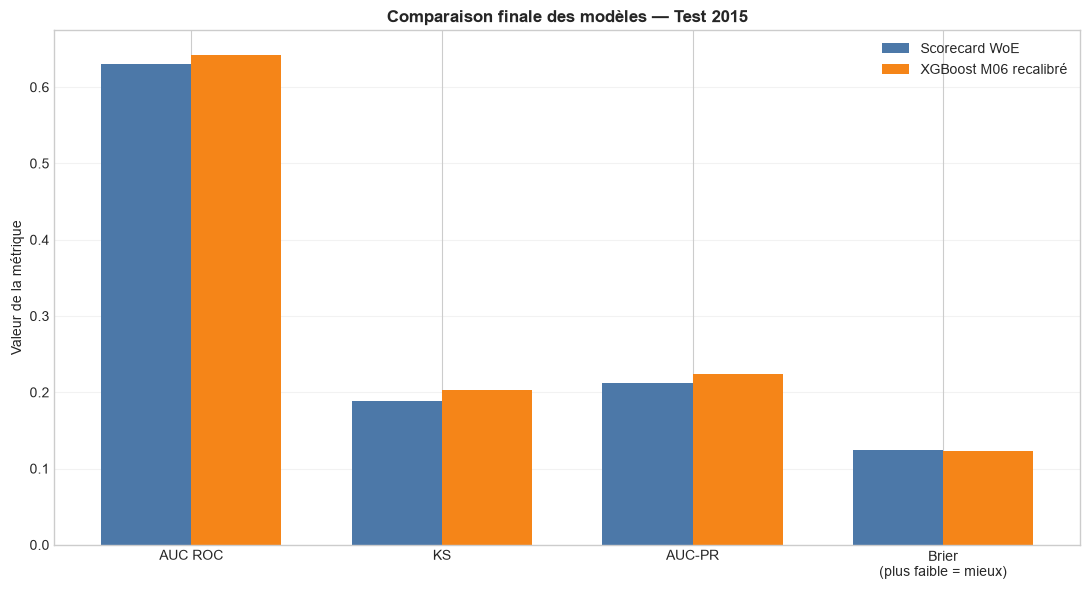

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/comparaison_finale_scorecard_xgboost.png


In [20]:
# ============================================================
# 18. VISUALISATION DE LA COMPARAISON FINALE
# ============================================================

COMPARAISON_FINALE_FILE = (
    OUTPUT_TABLES_DIR
    / "comparaison_finale_scorecard_xgboost.csv"
)

comparaison_finale_modeles = pd.read_csv(
    COMPARAISON_FINALE_FILE
)

scorecard_finale = comparaison_finale_modeles.loc[
    comparaison_finale_modeles["modèle"]
    == "Scorecard logistique WoE V1"
].iloc[0]

xgb_final = comparaison_finale_modeles.loc[
    comparaison_finale_modeles["modèle"]
    == "XGBoost M06 — PD recalibrées"
].iloc[0]

metriques_graphique = [
    "AUC_test",
    "KS_test",
    "AUC_PR_test",
    "Brier_test",
]

libelles = [
    "AUC ROC",
    "KS",
    "AUC-PR",
    "Brier\n(plus faible = mieux)",
]

positions = np.arange(len(metriques_graphique))
largeur = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    positions - largeur / 2,
    [
        scorecard_finale[metrique]
        for metrique in metriques_graphique
    ],
    width=largeur,
    label="Scorecard WoE",
    color="#4C78A8",
)

ax.bar(
    positions + largeur / 2,
    [
        xgb_final[metrique]
        for metrique in metriques_graphique
    ],
    width=largeur,
    label="XGBoost M06 recalibré",
    color="#F58518",
)

ax.set_xticks(positions)
ax.set_xticklabels(libelles)
ax.set_ylabel("Valeur de la métrique")

ax.set_title(
    "Comparaison finale des modèles — Test 2015",
    fontweight="bold",
)

ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

COMPARAISON_FIGURE_FILE = (
    OUTPUT_FIGURES_DIR
    / "comparaison_finale_scorecard_xgboost.png"
)

plt.savefig(
    COMPARAISON_FIGURE_FILE,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure exportée : "
    f"{COMPARAISON_FIGURE_FILE}"
)


In [21]:
# ============================================================
# 19. EXPORT DES ARTEFACTS — XGBOOST M06 CALIBRÉ
# ============================================================

# Vérification préalable : ces objets doivent être en mémoire.
objets_requis = [
    "modele_xgb_final",
    "preprocesseur_xgboost",
    "calibrateur_platt",
    "FEATURES_V1",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES",
    "FEATURES_XGBOOST",
    "n_arbres_xgb_final",
    "NOM_MODELE_FINAL",
]

objets_absents = [
    nom
    for nom in objets_requis
    if nom not in globals()
]

if objets_absents:
    raise RuntimeError(
        "Objets absents du kernel : "
        f"{objets_absents}. "
        "Relance les blocs de préparation, sélection M06 "
        "et calibration avant cet export."
    )

artefacts_xgboost_m06 = {
    "modele_xgboost": modele_xgb_final,
    "preprocesseur": preprocesseur_xgboost,
    "calibrateur_platt": calibrateur_platt,
    "features_sources": FEATURES_V1,
    "features_numeriques": NUMERIC_FEATURES,
    "features_categorielles": CATEGORICAL_FEATURES,
    "features_apres_encodage": FEATURES_XGBOOST,
    "n_arbres_retenus": n_arbres_xgb_final,
    "nom_modele": NOM_MODELE_FINAL,
    "random_state": RANDOM_STATE,
    "version_probabilites": (
        "Platt scaling ajusté sur validation 2014"
    ),
}

ARTEFACT_XGB_FILE = (
    OUTPUT_MODELS_DIR
    / "xgboost_m06_calibre.joblib"
)

MODELE_XGB_JSON_FILE = (
    OUTPUT_MODELS_DIR
    / "xgboost_m06_modele.json"
)

# Bundle Python complet pour le scoring.
joblib.dump(
    artefacts_xgboost_m06,
    ARTEFACT_XGB_FILE,
)

# Format natif XGBoost, utile pour interopérabilité et archivage.
modele_xgb_final.save_model(
    MODELE_XGB_JSON_FILE
)

# Manifest des sorties principales du benchmark.
manifest_xgb = pd.DataFrame(
    {
        "artefact": [
            "Bundle XGBoost + préprocesseur + calibrateur",
            "Modèle XGBoost natif",
            "Comparaison finale",
            "Synthèse des gains",
            "Bandes de risque test",
            "Importance par permutation",
            "PSI des PD",
        ],
        "fichier": [
            str(ARTEFACT_XGB_FILE),
            str(MODELE_XGB_JSON_FILE),
            str(COMPARAISON_FINALE_FILE),
            str(GAIN_XGB_FILE),
            str(BANDES_XGB_FILE),
            str(IMPORTANCE_PERMUTATION_FILE),
            str(PSI_XGB_FILE),
        ],
    }
)

MANIFEST_XGB_FILE = (
    OUTPUT_TABLES_DIR
    / "xgboost_m06_manifest.csv"
)

manifest_xgb.to_csv(
    MANIFEST_XGB_FILE,
    index=False,
)

display(manifest_xgb)

print(
    f"Bundle de scoring exporté : "
    f"{ARTEFACT_XGB_FILE}"
)

print(
    f"Modèle natif exporté : "
    f"{MODELE_XGB_JSON_FILE}"
)

print(
    f"Manifest exporté : "
    f"{MANIFEST_XGB_FILE}"
)


,artefact,fichier
0,Bundle XGBoost + préprocesseur + calibrateur,/Users/kwamekristianlaban/Documents/Projet_per...
1,Modèle XGBoost natif,/Users/kwamekristianlaban/Documents/Projet_per...
2,Comparaison finale,/Users/kwamekristianlaban/Documents/Projet_per...
3,Synthèse des gains,/Users/kwamekristianlaban/Documents/Projet_per...
4,Bandes de risque test,/Users/kwamekristianlaban/Documents/Projet_per...
5,Importance par permutation,/Users/kwamekristianlaban/Documents/Projet_per...
6,PSI des PD,/Users/kwamekristianlaban/Documents/Projet_per...


Bundle de scoring exporté : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/models/xgboost_m06_calibre.joblib
Modèle natif exporté : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/models/xgboost_m06_modele.json
Manifest exporté : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/xgboost_m06_manifest.csv


## Conclusion du benchmark XGBoost

### Résultat empirique

XGBoost M06 recalibré est le meilleur modèle prédictif sur le test temporel 2015.

Il obtient une AUC de 0,6421, un Gini de 0,2843, un KS de 0,2024 et une AUC-PR de 0,2236, contre respectivement 0,6300, 0,2600, 0,1885 et 0,2126 pour la scorecard logistique WoE.

La calibration par Platt scaling réduit le Brier test de 0,2420 à 0,1229, sans modifier le ranking. Le Brier recalibré est légèrement inférieur à celui de la scorecard, à 0,1238.

Le PSI train-test de XGBoost est de 0,0146, très inférieur au seuil de surveillance de 0,10. La distribution des PD est donc stable dans le temps.

### Recommandation métier

- Retenir **XGBoost M06 recalibré** lorsque la priorité est la précision
  prédictive, le classement du risque et l'estimation des probabilités
  de défaut.

- Conserver la **scorecard logistique WoE** comme modèle de référence
  interprétable, solution de repli et support de gouvernance.

- Utiliser les bandes de risque XGBoost pour guider la politique de
  crédit : acceptation plus fluide en bandes 1–2, analyse standard en
  bande 3, et revue renforcée en bandes 4–5.

- Mettre en place un monitoring périodique de l'AUC, du Brier, du taux
  de défaut observé par bande et du PSI.

- Investiguer toute dérive de PSI supérieure ou égale à 0,10, ou tout
  écart durable entre PD prédites et défauts observés ; recalibrer ou
  réentraîner le modèle si nécessaire.

### Limites

Le gain de XGBoost est réel mais modéré. Les résultats sont spécifiques aux prêts Lending Club sur 36 mois, aux variables disponibles à
l'octroi et au test temporel 2015.

Les importances des variables sont prédictives et non causales. Une mise en production exigerait également une validation de gouvernance,
des contrôles de biais, une documentation des données et une revue régulière sur des périodes plus récentes.
